In [ ]:
from sage.groups.braid import BraidGroup

R.<q,t,a> = LaurentPolynomialRing(QQ, 3)


class TorusKnot:
    """
    A class representing a torus knot with associated binary lists.

    The braid is stored as a *polynomial of braids*: ``self.braid`` is a list of
    ``(coefficient, braid)`` pairs, where each coefficient lives in
    ``R.<q,t,a> = LaurentPolynomialRing(QQ, 3)`` and each braid is an element of
    its own ``BraidGroup`` (different terms may have different strand counts).

    Internally the polynomial is kept as ``self.terms``: a list of dicts, each one
    state ``{'coeff', 'list1', 'list2', 'word'}``. A knot built from a single braid
    word is the one-term polynomial ``1 * braid``, so all single-braid behaviour is
    unchanged.
    """

    def __init__(self, list1, list2, braid_word=None):
        """Initialize a TorusKnot object.

        The two binary lists may have different lengths, but they must contain
        the same number of 1s.
        """

        # Validate that lists are binary (contain only 0s and 1s)
        for lst in [list1, list2]:
            if not all(x in [0, 1] for x in lst):
                raise ValueError("Lists must be binary (contain only 0s and 1s)")

        if sum(list1) != sum(list2):
            raise ValueError("Lists must contain the same number of 1s")

        l1 = list(list1)
        l2 = list(list2)
        word = list(braid_word) if braid_word is not None else []

        # Number of strands is the sum of the lengths minus the number of ones in list2
        n0 = len(l1) + len(l2) - sum(l2)
        if n0 <= 0:
            raise ValueError("Number of strands must be positive after applying rule")

        # Braid groups are created on demand and cached by strand count, since
        # different polynomial terms may live in braid groups of different sizes.
        self._braid_groups = {}

        # One term per state; a single braid word is the one-term polynomial 1*braid.
        self.terms = [{'coeff': R.one(), 'list1': l1, 'list2': l2, 'word': word}]

    # ---- backwards-compatible single-term accessors ----
    @property
    def list1(self):
        return self.terms[0]['list1']

    @property
    def list2(self):
        return self.terms[0]['list2']

    @property
    def braid_word(self):
        return self.terms[0]['word']

    @property
    def n(self):
        return self._term_n(self.terms[0])

    @property
    def braid_group(self):
        return self._braid_group(self._term_n(self.terms[0]))

    def _term_n(self, term):
        """Number of strands for one polynomial term."""
        return len(term['list1']) + len(term['list2']) - sum(term['list2'])

    def _braid_group(self, n):
        """Return (and cache) BraidGroup(n)."""
        if n not in self._braid_groups:
            self._braid_groups[n] = BraidGroup(n)
        return self._braid_groups[n]

    def _term_braid(self, term):
        """Return the Braid (group element) for one polynomial term."""
        G = self._braid_group(self._term_n(term))
        if term['word']:
            return G(term['word'])
        return G.one()

    @property
    def braid(self):
        """The braid polynomial as a list of (coefficient, braid) pairs."""
        return [(term['coeff'], self._term_braid(term)) for term in self.terms]

    def _poly_str(self):
        parts = [f"({coeff})*[{b}]" for coeff, b in self.braid]
        return " + ".join(parts) if parts else "0"

    def __repr__(self):
        return (f"TorusKnot(list1={self.list1}, list2={self.list2}, braid={self._poly_str()})")

    def __str__(self):
        lines = ["Torus Knot (braid polynomial):"]
        for k, term in enumerate(self.terms):
            lines.append(
                f"  Term {k}: coeff={term['coeff']}, "
                f"list1={term['list1']}, list2={term['list2']}, word={term['word']}"
            )
        return "\n".join(lines)

    def _compute_permutation_from_word(self, word, n):
        """Compute the strand permutation induced by a braid word (fallback)."""
        if not word:
            return list(range(n))
        positions = list(range(n))
        for g in word:
            idx = abs(int(g)) - 1
            if idx < 0 or idx + 1 >= n:
                continue
            positions[idx], positions[idx + 1] = positions[idx + 1], positions[idx]
        perm = [0] * n
        for final_pos, orig in enumerate(positions):
            perm[orig] = final_pos
        return perm

    def _strand_components(self, word, n):
        """Return component id for each strand index (0-based) for one braid word."""
        perm = None
        try:
            G = self._braid_group(n)
            braid = G(word) if word else G.one()
            if hasattr(braid, 'permutation'):
                p = braid.permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
            elif hasattr(braid, 'to_permutation'):
                p = braid.to_permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
        except Exception:
            perm = None

        if perm is None:
            perm = self._compute_permutation_from_word(word, n)

        visited = [False] * n
        comp_id = [-1] * n
        cid = 0
        for i in range(n):
            if visited[i]:
                continue
            cycle = []
            cur = i
            while not visited[cur]:
                visited[cur] = True
                cycle.append(cur)
                cur = perm[cur]
            for v in cycle:
                comp_id[v] = cid
            cid += 1
        return comp_id

    def simplify_1_on_top(self, index=0):
        """Apply the simplification rule based on the first braid letter of term `index`."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0])) - 1
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i >= len(l1) - 1:
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i+1] != 1:
            print("Strand at index", i+1, "is not 1 in list1:", l1)
            return False
        l1[i], l1[i+1] = l1[i+1], l1[i]
        word.pop(0)
        return True

    def simplify_0s_vertical(self, index=0):
        """If the first braid letter s_val of term `index` crosses two 0-strands in
        list1, pop it and append s_{val+x} to the braid word, where
        x = (length of list2) - (number of 1s in list1 before list1[val-1])."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            val = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        i = val - 1
        if i < 0 or i + 1 >= len(l1):
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i] != 0 or l1[i + 1] != 0:
            print("Strands at index", i, "and", i+1, "are not both 0 in list1:", l1)
            return False
        word.pop(0)
        x = len(l2) - sum(l1[:i])
        word.append(val + x)
        return True

    def simplify_0s_first(self, index=0):
        """If list1[0] and list2[0] are both 0 and no braid letter is s_1
        (no letter with |value| == 1), split term `index` into two terms.

        Strand 1 is removed (it is uncrossed), so every braid letter shifts down
        by one (|value| -> |value| - 1, sign preserved). In both terms list1[0] and
        list2[0] are removed; then:
          Term 1: append the old list2[0] to list1 and the old list1[0] to list2;
                  coefficient gains a factor q * t^(-A).
          Term 2: append a 1 to the end of both list1 and list2;
                  coefficient gains a factor t^(-A).
        Here A is the number of 1s in the original list1. The factors mirror the
        U[0]==V[0]==0 branch of the HHH recursion.
        """
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not l1 or not l2:
            print("Lists are empty, cannot simplify.")
            return False
        if l1[0] != 0 or l2[0] != 0:
            print("list1[0] and list2[0] are not both 0:", l1[0], l2[0])
            return False
        if any(abs(int(g)) == 1 for g in word):
            print("A braid letter is s_1; cannot simplify.")
            return False

        old_l1_0 = l1[0]
        old_l2_0 = l2[0]
        rest1 = l1[1:]
        rest2 = l2[1:]

        # strand 1 is removed -> shift every generator's index down by one
        shifted = [g - 1 if g > 0 else g + 1 for g in word]

        A = sum(l1)  # number of 1s in the original list1
        tfac = t ** (-A)
        coeff = term['coeff']

        term1 = {'coeff': coeff * q * tfac,
                 'list1': rest1 + [old_l2_0],
                 'list2': rest2 + [old_l1_0],
                 'word': list(shifted)}
        term2 = {'coeff': coeff * tfac,
                 'list1': rest1 + [1],
                 'list2': rest2 + [1],
                 'word': list(shifted)}

        self.terms[index:index + 1] = [term1, term2]
        return True

    def simplify_0s_horizontal(self, index=0):
        """Look at the first braid letter s_i of term `index`. The case
        i < len(list1) belongs to simplify_0s_vertical, so the move is refused.
        Otherwise set k = i - len(list1) (0-based offset into list2's zeros).
        Require: the (k+1)th and (k+2)th zeros of list2 exist, with no 1s
        strictly between them in list2. On success, pop the first letter and
        append j to the braid word, where j is the 1-based position of the
        (k+1)th zero in list2."""
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i <= len(l1):
            print(f"First braid letter i={i} <= len(list1)={len(l1)}; this case belongs to simplify_0s_vertical (or is the boundary crossing).")
            return False
        k = i - len(l1) - 1
        zero_positions = [m for m, v in enumerate(l2) if v == 0]
        if len(zero_positions) < k + 2:
            print(f"list2 has only {len(zero_positions)} zero(s); need at least {k + 2}.")
            return False
        pos_a = zero_positions[k]
        pos_b = zero_positions[k + 1]
        between = l2[pos_a + 1:pos_b]
        if any(v == 1 for v in between):
            print("There is a 1 between the chosen zeros in list2:", between)
            return False
        word.pop(0)
        j = pos_a + 1  # 1-based position of the (k+1)th zero in list2
        word.append(j)
        return True

    def can_move_letter_to_front(self, position, index=0):
        """Test whether the braid letter at `position` in term `index`'s word
        can be brought to the front of the braid using only braid relations
        (no inverses introduced).

        Idea (mirrors labels_test): if g is the chosen letter and b is the
        term's braid, then b can be written as g * c for some positive braid c
        iff g^{-1} * b reduces (via Garside left normal form) to a braid whose
        Tietze word has no negative entries.

        Returns (True, new_word) on success, where new_word is the rewritten
        braid word with the chosen letter first; or (False, None) otherwise.
        Does not mutate the term.
        """
        term = self.terms[index]
        word = term['word']
        if not (0 <= position < len(word)):
            print(f"position {position} out of range for word of length {len(word)}")
            return False, None
        val = int(word[position])
        if val == 0:
            print("invalid generator 0 in braid word")
            return False, None
        n = self._term_n(term)
        G = self._braid_group(n)
        braid = G(word)
        # inverse of the chosen generator
        if val > 0:
            gen_inv = G.gen(val - 1) ** -1
        else:
            gen_inv = G.gen(-val - 1)
        candidate = gen_inv * braid
        # rebuild from left normal form to get the canonical Tietze
        reduced = G.one()
        for factor in candidate.left_normal_form():
            reduced = reduced * factor
        tz = list(reduced.Tietze())
        if tz and min(tz) < 0:
            return False, None
        return True, [val] + tz

    def visualize(self, figsize=(6,4), show=True, savepath=None):
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=figsize)
        width = 1.75
        inset = 0.12

        ax.plot([0, width, width, 0, 0], [0, 0, 1, 1, 0], color='black')

        n1 = len(self.list1)
        if n1 == 0:
            left_xs, left_ys = [], []
        elif n1 == 1:
            left_xs, left_ys = [0.0], [0.5]
        else:
            left_xs = [0.0] * n1
            left_ys = [inset + i * ((1 - 2 * inset) / (n1 - 1)) for i in range(n1)]

        n2 = len(self.list2)
        if n2 == 0:
            bottom_xs, bottom_ys = [], []
        elif n2 == 1:
            bottom_xs, bottom_ys = [width / 2], [0.0]
        else:
            bottom_xs = [inset + i * ((width - 2 * inset) / (n2 - 1)) for i in range(n2)]
            bottom_ys = [0.0] * n2

        zero_indices = [i for i, value in enumerate(self.list2) if value == 0]
        top_xs_all = [bottom_xs[i] for i in zero_indices]
        top_ys_all = [1.0] * len(top_xs_all)
        top_zero_indices = sorted(zero_indices, key=lambda i: bottom_xs[i])

        extra_left = max(0, n1 - n2)
        extra_bottom = max(0, n2 - n1)

        top_extension_count = min(len(top_zero_indices), extra_bottom)
        top_to_bottom_indices = top_zero_indices[:top_extension_count]
        remaining_top_zero_indices = top_zero_indices[top_extension_count:]
        remaining_bottom_indices = list(range(n1 + top_extension_count, n2)) if extra_bottom > top_extension_count else []

        rhs_count = extra_left + len(remaining_top_zero_indices) + len(remaining_bottom_indices)
        if rhs_count > 0:
            right_xs = [width] * rhs_count
            right_ys = [inset + i * ((1 - 2 * inset) / (rhs_count - 1)) for i in range(rhs_count)] if rhs_count > 1 else [0.5]
        else:
            right_xs, right_ys = [], []

        segments = []
        pair_count = min(n1, n2)
        for i in range(pair_count):
            segments.append((left_xs[i], left_ys[i], bottom_xs[i], bottom_ys[i]))

        rhs_cursor = 0
        for j in range(extra_left):
            i = n2 + j
            segments.append((left_xs[i], left_ys[i], right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            segments.append((x_top, 1.0, x_bottom, 0.0))

        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            segments.append((x_top, 1.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            segments.append((bottom_xs[bottom_idx], 0.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        def vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03):
            ys = []
            for (x1, y1_s, x2, y2_s) in segments:
                if x1 == x2:
                    continue
                if not (min(x1, x2) <= x0 <= max(x1, x2)):
                    continue
                t = (x0 - x1) / (x2 - x1)
                y_at = y1_s + t * (y2_s - y1_s)
                if min(y1_s, y2_s) <= y_at <= max(y1_s, y2_s):
                    ys.append(y_at)
            ys = sorted(set(ys))
            intervals = [(y0, y1)]
            for y in ys:
                new_intervals = []
                low = y - gap
                high = y + gap
                for (a, b) in intervals:
                    if high <= a or low >= b:
                        new_intervals.append((a, b))
                    else:
                        if a < low:
                            new_intervals.append((a, low))
                        if high < b:
                            new_intervals.append((high, b))
                intervals = new_intervals
            return [(x0, x0, a, b) for (a, b) in intervals if (b - a) > 1e-4]

        for i in zero_indices:
            x0 = bottom_xs[i]
            segs = vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03)
            for (_x1, _x2, ya, yb) in segs:
                ax.plot([x0, x0], [ya, yb], color='0.35', linewidth=1.2, zorder=0)

        for i in range(pair_count):
            ax.plot([left_xs[i], bottom_xs[i]], [left_ys[i], bottom_ys[i]], color='gray', linewidth=1.5, zorder=1)

        for j in range(extra_left):
            i = n2 + j
            ax.plot([left_xs[i], right_xs[j]], [left_ys[i], right_ys[j]], color='gray', linewidth=1.5, zorder=1)

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            ax.plot([x_top, x_bottom], [1.0, 0.0], color='gray', linewidth=1.5, zorder=1)

        rhs_cursor = extra_left
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            ax.plot([x_top, right_xs[rhs_cursor]], [1.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            ax.plot([bottom_xs[bottom_idx], right_xs[rhs_cursor]], [0.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        ax.scatter(left_xs, left_ys, color='blue', zorder=5)
        ax.scatter(bottom_xs, bottom_ys, color='red', zorder=5)
        if right_xs:
            ax.scatter(right_xs, right_ys, color='green', zorder=5)
        if top_xs_all:
            ax.scatter(top_xs_all, top_ys_all, color='purple', zorder=5)

        for i, (x, y) in enumerate(zip(left_xs, left_ys)):
            ax.text(x - 0.03 * width, y, str(self.list1[i]), verticalalignment='center', horizontalalignment='right')
        for i, (x, y) in enumerate(zip(bottom_xs, bottom_ys)):
            ax.text(x, y - 0.03, str(self.list2[i]), verticalalignment='top', horizontalalignment='center')

        ax.set_xlim(-0.1 * width, 1.15 * width)
        ax.set_ylim(-0.1, 1.1)
        ax.set_aspect('equal')
        ax.axis('off')

        if savepath:
            fig.savefig(savepath, bbox_inches='tight')
        if show:
            plt.show()
        return fig, ax

    def _plot_one(self, term, ax=None, colors=None, three_d=False, savepath=None):
        """Render a single polynomial term (its braid) into `ax` (or a new figure)."""
        import tempfile
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg

        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        n = self._term_n(term)
        braid = self._term_braid(term)

        # if no explicit colors provided, color by link component
        if colors is None:
            try:
                import matplotlib.cm as cm
                import matplotlib.colors as mcolors
                comp_ids = self._strand_components(word, n)
                cmap = cm.get_cmap('tab10')
                comp_to_color = {}
                for cid in sorted(set(comp_ids)):
                    comp_to_color[cid] = mcolors.to_hex(cmap(len(comp_to_color) % 10))
                colors = [comp_to_color[cid] for cid in comp_ids]
            except Exception:
                colors = None

        if three_d:
            braid_plot = braid.plot3d() if colors is None else braid.plot3d(color=colors)
            if savepath:
                braid_plot.save(savepath)
            braid_plot.show()
            return

        # 2D: render Sage plot to a temp PNG, load as numpy array, rotate, display via matplotlib
        braid_plot = braid.plot() if colors is None else braid.plot(color=colors)

        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.png')
        tmp.close()
        try:
            # Render via matplotlib figure to get exact strand pixel positions from transform
            fig_sage = braid_plot.matplotlib()
            fig_sage.canvas.draw()
            ax_sage = fig_sage.axes[0]
            dpi_sage = fig_sage.dpi
            y_ref = ax_sage.get_ylim()[0]
            strand_cols = [
                ax_sage.transData.transform((float(i), y_ref))[0]
                for i in range(max(len(l1), len(l2)))
            ]
            fig_sage.savefig(tmp.name, dpi=dpi_sage)
            plt.close(fig_sage)

            img = mpimg.imread(tmp.name)           # shape: (H, W, C)
            H_orig, W_orig = img.shape[:2]
            # rotate 90° clockwise, then flip vertically so strand 1 ends up at the bottom
            img_rotated = np.flipud(np.rot90(img, k=3))

            # Crop the wide whitespace borders Sage bakes into the braid PNG so the
            # strand endpoints reach the panel edges (labels can then sit right next
            # to the strands).
            gray = img_rotated[..., :3].mean(axis=-1) if img_rotated.ndim == 3 else img_rotated
            mask = gray < 0.99
            ys_nz, xs_nz = np.where(mask)
            if xs_nz.size > 0:
                pad = 4
                y0 = max(0, int(ys_nz.min()) - pad)
                y1 = min(img_rotated.shape[0], int(ys_nz.max()) + pad + 1)
                x0 = max(0, int(xs_nz.min()) - pad)
                x1 = min(img_rotated.shape[1], int(xs_nz.max()) + pad + 1)
                img_rotated = img_rotated[y0:y1, x0:x1]
            else:
                y0 = 0

            h, w = img_rotated.shape[:2]
            label_offset = 12
            own_fig = ax is None
            if own_fig:
                fig, ax = plt.subplots(figsize=(w / 100, h / 100))
            ax.imshow(img_rotated)
            ax.set_xlim(-label_offset, w - 0.5 + label_offset)
            ax.axis('off')

            # Label the first len(list1) strands: strand i gets s_{list1[i]}
            # strand at col_px in original -> y_pix = W_orig-1-col_px after rot90+flipud,
            # shifted up by the amount we cropped off the top (y0).
            for val, col_px in zip(l1, strand_cols):
                y_pix = (W_orig - 1 - col_px) - y0
                ax.text(-2, y_pix, str(val), ha='right', va='center', fontsize=10)

            for val, col_px in zip(l2, strand_cols):
                y_pix = (W_orig - 1 - col_px) - y0
                ax.text(w + 2, y_pix, str(val), ha='left', va='center', fontsize=10)

            if own_fig:
                plt.tight_layout(pad=0)
                if savepath:
                    fig.savefig(savepath, bbox_inches='tight', dpi=100)
                plt.show()
        finally:
            if os.path.exists(tmp.name):
                os.remove(tmp.name)

    def plot_braid(self, colors=None, three_d=False, savepath=None, ax=None):
        """Plot every term of the braid polynomial, rotated 90° clockwise with
        strand 1 at the bottom.

        A single-term polynomial plots one braid and honours an external ``ax``
        (so it can be dropped into a grid), exactly like before. A multi-term
        polynomial gets one subplot per term, titled with the term's coefficient.

        Parameters
        ----------
        colors : list, optional
            List of colors for each strand. If None, colors are generated so strands
            belonging to the same link component share the same color.
        three_d : bool, optional
            If True, use the braid's 3D plot when available.
        savepath : str, optional
            Path to save the plot to a file.
        ax : matplotlib axes, optional
            Target axes for a single-term polynomial.
        """
        import math
        import matplotlib.pyplot as plt

        terms = self.terms

        # single-term: behave exactly like the original single-braid plot
        if len(terms) == 1:
            self._plot_one(terms[0], ax=ax, colors=colors, three_d=three_d, savepath=savepath)
            return

        # multi-term: one subplot per term, titled by coefficient
        ncols = min(len(terms), 3)
        nrows = math.ceil(len(terms) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
        axes = axes.flatten()
        for term, ax_i in zip(terms, axes):
            self._plot_one(term, ax=ax_i, colors=colors)
            ax_i.set_title(str(term['coeff']))
        for ax_i in axes[len(terms):]:
            ax_i.axis('off')
        plt.tight_layout()
        if savepath:
            fig.savefig(savepath, bbox_inches='tight', dpi=100)
        plt.show()


Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 0, 0, 0, 1, 0], list2=[0, 0, 0, 0, 0, 0, 0, 1, 0], word=[1, 3, 5, 7, 9, 11, 13, 15]
TorusKnot(list1=[0, 0, 0, 0, 0, 0, 0, 1, 0], list2=[0, 0, 0, 0, 0, 0, 0, 1, 0], braid=(1)*[s0*s2*s4*s6*s8*s10*s12*s14])
Before simplify: Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 0, 0, 0, 1, 0], list2=[0, 0, 0, 0, 0, 0, 0, 1, 0], word=[1, 3, 5, 7, 9, 11, 13, 15]


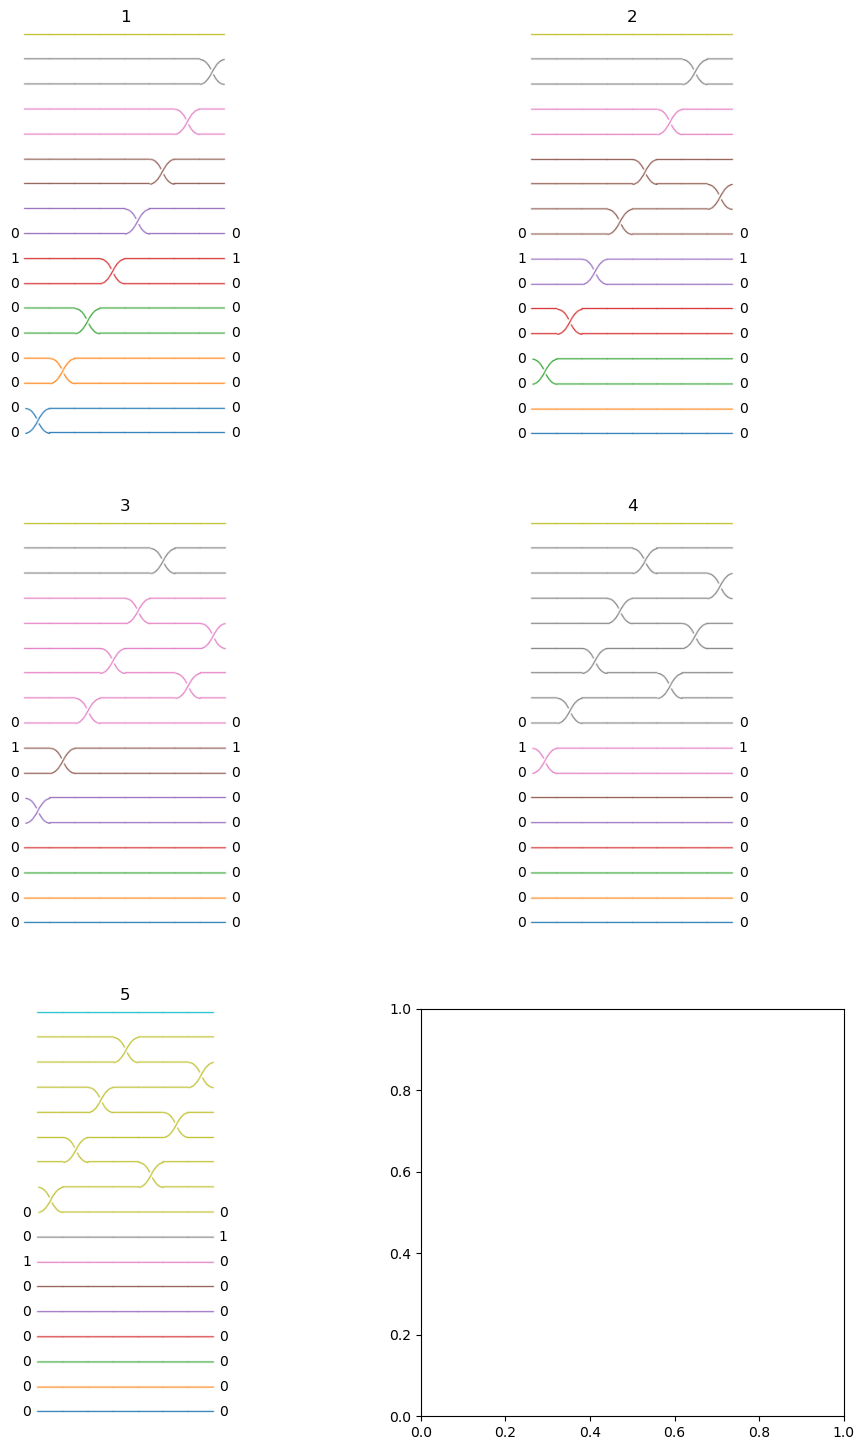

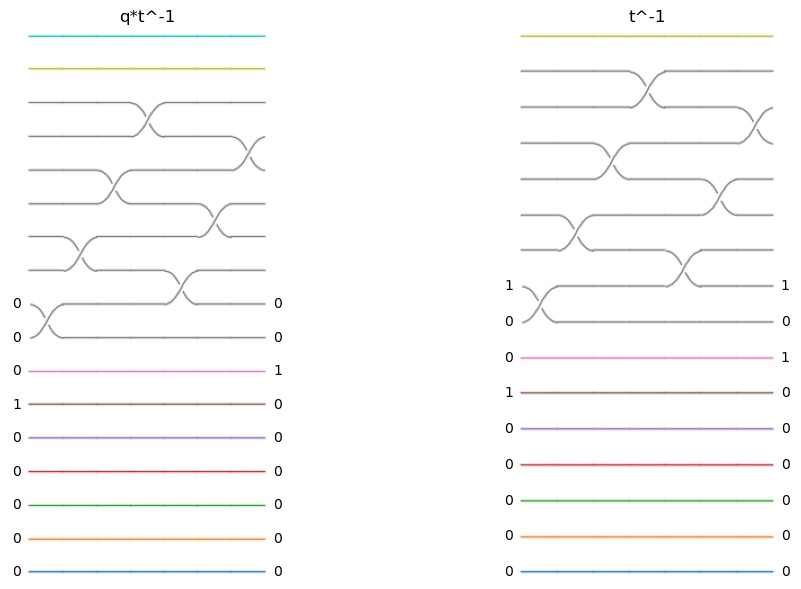

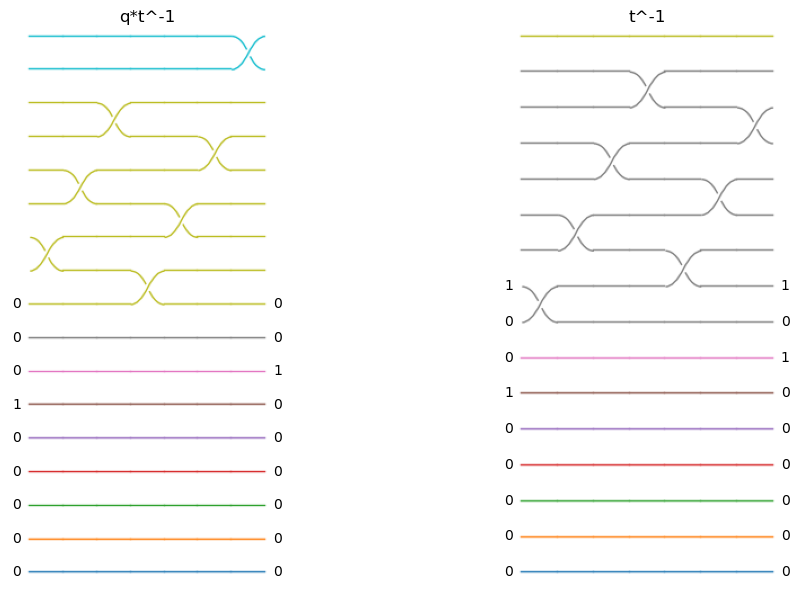

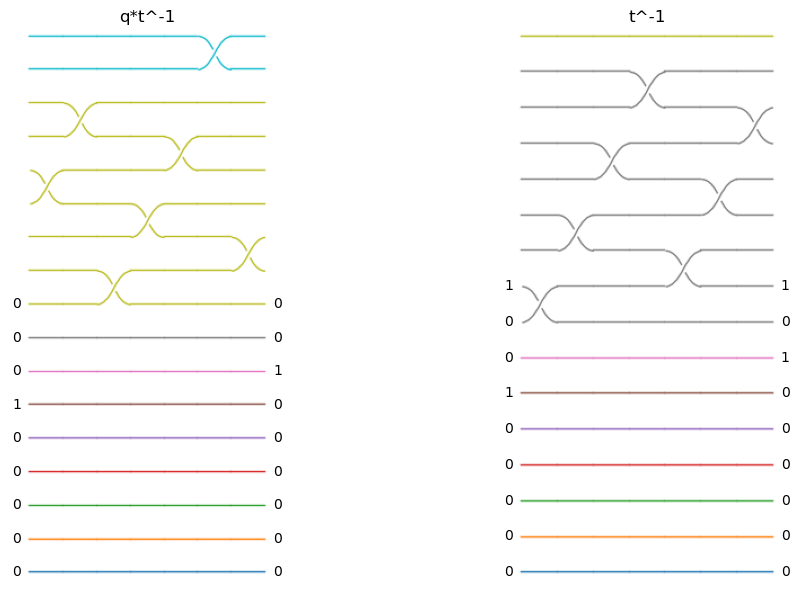

Torus Knot (braid polynomial):
  Term 0: coeff=q*t^-1, list1=[0, 0, 0, 0, 0, 1, 0, 0, 0], list2=[0, 0, 0, 0, 0, 0, 1, 0, 0], word=[12, 14, 9, 11, 13, 16, 10]
  Term 1: coeff=t^-1, list1=[0, 0, 0, 0, 0, 1, 0, 0, 1], list2=[0, 0, 0, 0, 0, 0, 1, 0, 1], word=[8, 10, 12, 14, 9, 11, 13]


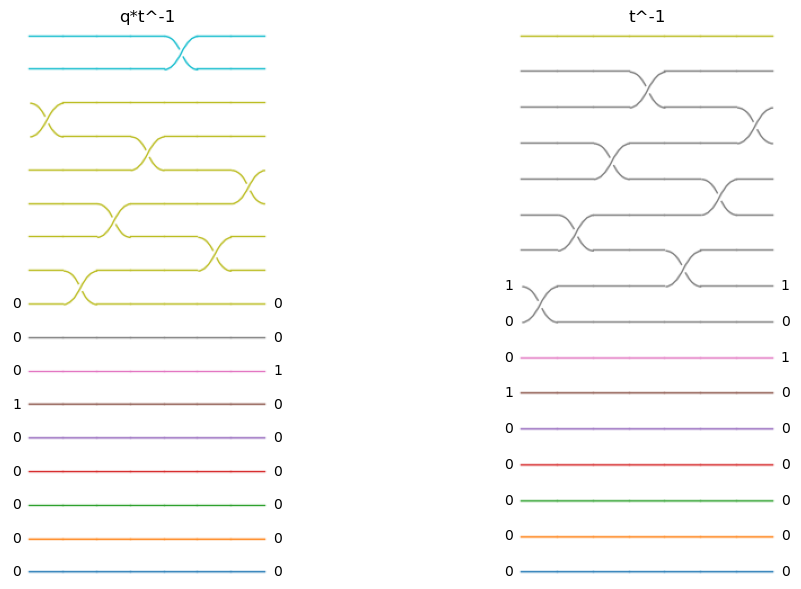

<Figure size 640x480 with 0 Axes>

In [91]:
# Example usage of TorusKnot class

# Create a simple torus knot
list1 = [0, 0, 0, 0, 0, 0, 0, 1, 0]
list2 = [0, 0, 0, 0, 0, 0, 0, 1, 0]
braid_word = [1, 3, 5, 7, 9, 11, 13, 15]  # A simple braid word

tk = TorusKnot(list1, list2, braid_word)
print(tk)
print(repr(tk))

import matplotlib.pyplot as plt
import math

# Grid layout: set ncols to the width you want; nrows grows to fit npanels.
npanels = 5
ncols = 2
nrows = math.ceil(npanels / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
axes = axes.flatten()

# Render each state into the next grid cell (plot BEFORE mutating).
print("Before simplify:", tk)
tk.plot_braid(ax=axes[0])
axes[0].set_title("1")

applied = tk.simplify_0s_vertical()
tk.plot_braid(ax=axes[1])
axes[1].set_title("2")

applied = tk.simplify_0s_vertical()
tk.plot_braid(ax=axes[2])
axes[2].set_title("3")

applied = tk.simplify_0s_vertical()
tk.plot_braid(ax=axes[3])
axes[3].set_title("4")

applied = tk.simplify_1_on_top()
tk.plot_braid(ax=axes[4])
axes[4].set_title("5")

applied = tk.simplify_0s_first()
tk.plot_braid()

applied = tk.simplify_0s_vertical()
tk.plot_braid()

applied = tk.simplify_0s_horizontal()
tk.plot_braid()
print(tk)

applied = tk.simplify_0s_horizontal()
tk.plot_braid()

# hide any unused cells in the grid
for ax in axes[npanels:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

#tk2 = TorusKnot(list1, list2, [2, 1, 2])
#tk2.plot_braid()